In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False  

daily = pd.read_csv('../data/processed/daily_features.csv', parse_dates=['ActivityDate'])

In [7]:
# 사용자별 관찰 시작일 기준 경과일수(day_offset) 계산
first_day = daily.groupby('Id')['ActivityDate'].min().rename('start_date')
daily = daily.merge(first_day, on='Id')
daily['day_offset'] = (daily['ActivityDate'] - daily['start_date']).dt.days

In [8]:
# day_offset별 관찰 사용자 수 확인 (신뢰 가능한 구간 판단용)
n_users = daily.groupby('day_offset')['Id'].nunique()
print('day_offset별 사용자 수:')
print(n_users)

day_offset별 사용자 수:
day_offset
0     35
1     35
2     35
3     35
4     35
      ..
57     1
58     1
59     1
60     1
61     1
Name: Id, Length: 62, dtype: int64


신뢰 가능한 구간: 0 ~ 44일 (사용자 7명 이상)


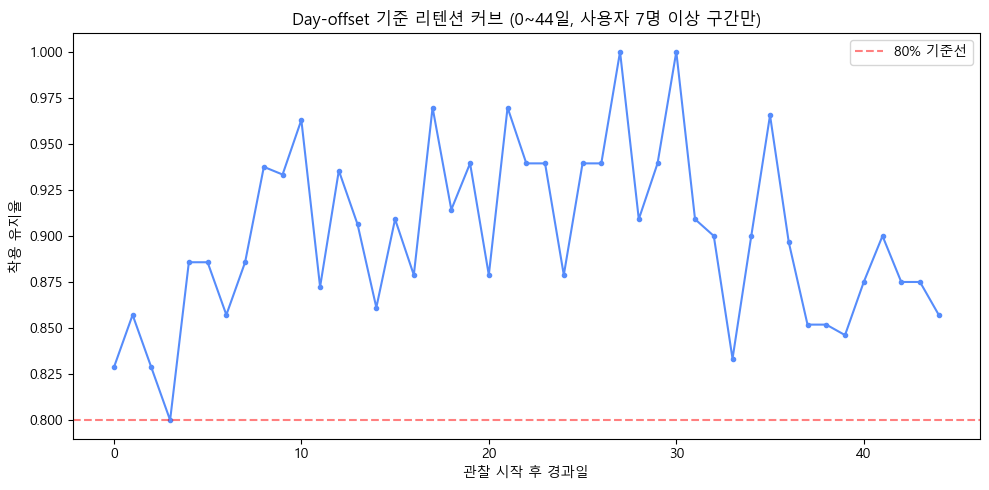

유지율이 80% 밑으로 처음 떨어진 시점: 없음 (신뢰구간 내)


In [9]:
# 경과일수별 착용 유지율 (리텐션 커브) - 사용자 7명 이상 구간만 사용
retention = daily.groupby('day_offset')['is_worn'].mean().reset_index()
retention.columns = ['day_offset', 'retention_rate']

valid_offsets = n_users[n_users >= 7].index
retention_trimmed = retention[retention['day_offset'].isin(valid_offsets)]
max_reliable_day = valid_offsets.max()

print(f'신뢰 가능한 구간: 0 ~ {max_reliable_day}일 (사용자 7명 이상)')

fig, ax = plt.subplots(figsize=(10,5))
ax.plot(retention_trimmed['day_offset'], retention_trimmed['retention_rate'], marker='o', markersize=3)
ax.axhline(0.8, color='red', linestyle='--', alpha=0.5, label='80% 기준선')
ax.set_xlabel('관찰 시작 후 경과일'); ax.set_ylabel('착용 유지율')
ax.set_title(f'Day-offset 기준 리텐션 커브 (0~{max_reliable_day}일, 사용자 7명 이상 구간만)')
ax.legend()
plt.tight_layout()
plt.savefig('../outputs/figures/05_retention_curve.png', dpi=130)
plt.show()

drop_point = retention_trimmed[retention_trimmed['retention_rate'] < 0.8]
print('유지율이 80% 밑으로 처음 떨어진 시점:', drop_point['day_offset'].min() if len(drop_point) else '없음 (신뢰구간 내)')

In [10]:
# 7일 이동평균 걸음수 - 사용자별 감소 시작 시점 탐지
# min_periods=7로 설정해 꽉 찬 7일 평균만 인정 (초반 불안정 구간 배제)
daily_sorted = daily.sort_values(['Id','ActivityDate'])
daily_sorted['steps_7day_ma'] = daily_sorted.groupby('Id')['TotalSteps'].transform(
    lambda s: s.rolling(7, min_periods=7).mean()
)

def find_decline_start(g):
    g = g[g['day_offset'] >= 7]   # 이동평균이 안정화된 이후만 비교
    if len(g) == 0 or g['steps_7day_ma'].isna().all():
        return None
    baseline = g['steps_7day_ma'].max()
    if pd.isna(baseline) or baseline == 0:
        return None
    declined = g[g['steps_7day_ma'] < baseline * 0.7]
    return declined['day_offset'].min() if len(declined) else None

decline_points = daily_sorted.groupby('Id').apply(find_decline_start).dropna()
print('감소가 관찰된 사용자 수:', len(decline_points), '/', daily['Id'].nunique())
print('감소 시작 시점(day_offset) 분포:')
print(decline_points.describe())

감소가 관찰된 사용자 수: 29 / 35
감소 시작 시점(day_offset) 분포:
count    29.000000
mean     12.413793
std       7.993378
min       7.000000
25%       7.000000
50%      10.000000
75%      15.000000
max      37.000000
dtype: float64


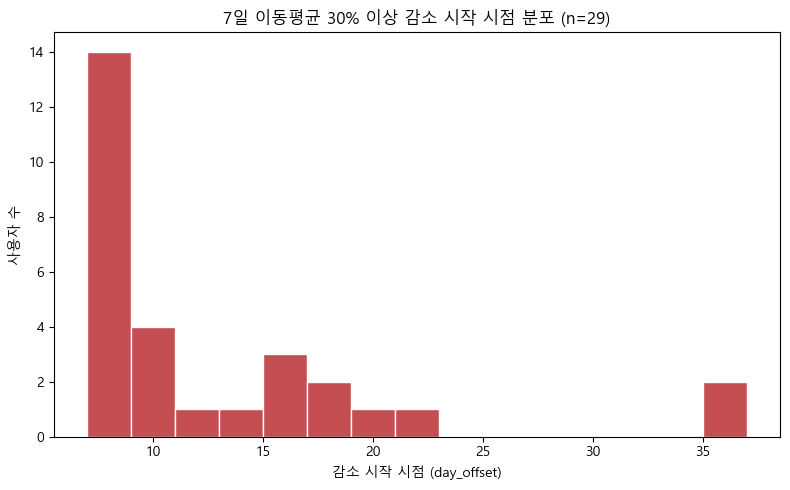

In [11]:
# 감소 시점 분포 시각화
fig, ax = plt.subplots(figsize=(8,5))
ax.hist(decline_points, bins=15, color='#C44E52', edgecolor='white')
ax.set_xlabel('감소 시작 시점 (day_offset)'); ax.set_ylabel('사용자 수')
ax.set_title(f'7일 이동평균 30% 이상 감소 시작 시점 분포 (n={len(decline_points)})')
plt.tight_layout()
plt.savefig('../outputs/figures/07_decline_distribution.png', dpi=130)
plt.show()

In [12]:
def find_baseline_day(g):
    g = g[g['day_offset'] >= 7]
    if len(g) == 0 or g['steps_7day_ma'].isna().all():
        return None
    return g.loc[g['steps_7day_ma'].idxmax(), 'day_offset']

baseline_days = daily_sorted.groupby('Id').apply(find_baseline_day).dropna()
print('baseline(최고 활동량) 시점 분포:')
print(baseline_days.describe())
print()
print('baseline이 7~9일차에 몰려있는 사용자 수:', ((baseline_days>=7)&(baseline_days<=9)).sum(), '/', len(baseline_days))

baseline(최고 활동량) 시점 분포:
count    35.000000
mean     21.885714
std      11.999440
min       7.000000
25%      11.000000
50%      18.000000
75%      32.500000
max      41.000000
dtype: float64

baseline이 7~9일차에 몰려있는 사용자 수: 7 / 35


Fitbit 착용 후 약 1주일(7~9일차) 시점에 활동량이 급감하는 사용자가 두드러지게 많다(29명 중 14명, 48%). 이는 baseline 활동량이 언제 기록되었는지와 무관하게 나타나는 패턴으로, 초기 동기부여가 약 일주일 뒤 꺾이는 전형적인 "신제품 사용 초기 이탈" 곡선과 일치한다. 다만 리텐션 커브(착용 유지율) 자체는 44일까지 뚜렷한 하락 없이 안정적이었다는 점에서, "활동량 감소"와 "기기 미착용/이탈"은 서로 다른 현상으로 봐야 한다 — 사용자들은 기기를 계속 차고는 있지만, 운동 강도/의욕은 일주일쯤 지나면 떨어지는 경향이 있다.